# Phase 2 - Feature Engineering
In this notebook I create new columns that make the data more useful.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/cleaned/ames_cleaned.csv")
df.head()

,Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,1st_Flr_SF,2nd_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Garage_Type,Garage_Yr_Blt,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,3Ssn_Porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,0,3,2010,WD,Normal,189900.0


In [2]:
# One-hot encode 2 categorical columns
dummies = pd.get_dummies(df[["Neighborhood", "MS_Zoning"]], drop_first=True)
print("Dummy columns created:", dummies.shape[1])

Dummy columns created: 33


In [3]:
# Ordinal encode 1 ordered text column
quality_map = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5, "None": 0}
df["Exter_Qual_Ord"] = df["Exter_Qual"].map(quality_map).fillna(0)
df[["Exter_Qual", "Exter_Qual_Ord"]].head()

,Exter_Qual,Exter_Qual_Ord
0,TA,3
1,TA,3
2,TA,3
3,Gd,4
4,TA,3


In [4]:
# Scale 2 numeric columns
scaler = StandardScaler()
df["Gr_Liv_Area_scaled"] = scaler.fit_transform(df[["Gr_Liv_Area"]])
df["Total_Bsmt_SF_scaled"] = scaler.fit_transform(df[["Total_Bsmt_SF"]])

df[["Gr_Liv_Area", "Gr_Liv_Area_scaled", "Total_Bsmt_SF", "Total_Bsmt_SF_scaled"]].head()

,Gr_Liv_Area,Gr_Liv_Area_scaled,Total_Bsmt_SF,Total_Bsmt_SF_scaled
0,1656,0.309265,1080.0,0.064492
1,896,-1.194427,882.0,-0.385032
2,1329,-0.337718,1329.0,0.629802
3,2110,1.207523,2110.0,2.402924
4,1629,0.255844,928.0,-0.280597


In [5]:
# Create useful domain features
df["price_per_sqft"] = df["SalePrice"] / df["Gr_Liv_Area"].replace(0, np.nan)
df["price_per_sqft"] = df["price_per_sqft"].fillna(0)

df["total_bathrooms"] = (
    df["Full_Bath"]
    + 0.5 * df["Half_Bath"]
    + df["Bsmt_Full_Bath"]
    + 0.5 * df["Bsmt_Half_Bath"]
)

# One more useful feature
df["House_Age"] = df["Yr_Sold"] - df["Year_Built"]

df[["price_per_sqft", "total_bathrooms", "House_Age"]].head()

,price_per_sqft,total_bathrooms,House_Age
0,129.830918,2.0,50
1,117.187500,1.0,49
2,129.420617,1.5,52
3,115.639810,3.5,42
4,116.574586,2.5,13


In [6]:
# Interaction feature
df["quality_x_area"] = df["Overall_Qual"] * df["Gr_Liv_Area"]
df[["Overall_Qual", "Gr_Liv_Area", "quality_x_area"]].head()

,Overall_Qual,Gr_Liv_Area,quality_x_area
0,6,1656,9936
1,5,896,4480
2,6,1329,7974
3,7,2110,14770
4,5,1629,8145


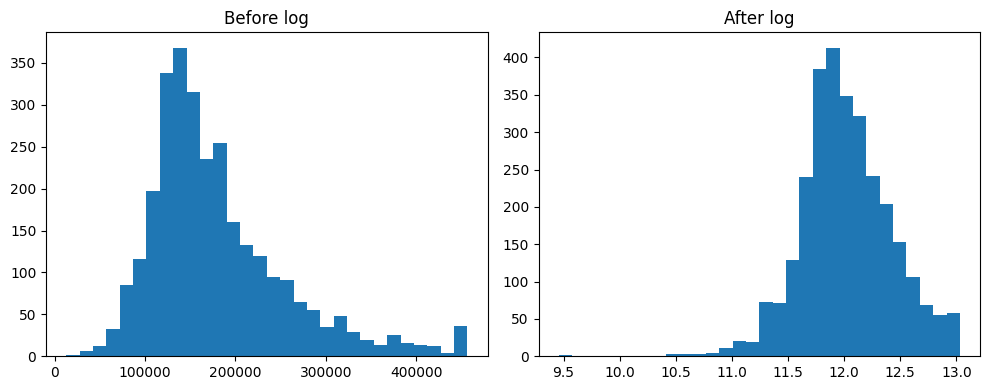

In [7]:
# Log transform a skewed column
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df["SalePrice"], bins=30)
plt.title("Before log")

plt.subplot(1, 2, 2)
df["log_SalePrice"] = np.log1p(df["SalePrice"])
plt.hist(df["log_SalePrice"], bins=30)
plt.title("After log")

plt.tight_layout()
plt.show()

In [8]:
# Bin one column into groups
df["House_Age_Group"] = pd.cut(
    df["House_Age"],
    bins=[-1, 10, 30, 200],
    labels=["New", "Recent", "Old"]
)

df["House_Age_Group"].value_counts()

House_Age_Group
Old       1622
New        877
Recent     430
Name: count, dtype: int64

In [9]:
# Join the dummy columns
df = pd.concat([df, dummies], axis=1)

# Remove very highly correlated numeric features
corr = df.select_dtypes(include=np.number).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

# Keep the target and log target
to_drop = [col for col in to_drop if col not in ["SalePrice", "log_SalePrice"]]

features_df = df.drop(columns=to_drop)

print("Columns removed because of very high correlation:", to_drop)
print("Final shape:", features_df.shape)

Columns removed because of very high correlation: ['Yr_Sold', 'Gr_Liv_Area_scaled', 'Total_Bsmt_SF_scaled', 'House_Age']
Final shape: (2930, 115)


In [10]:
features_df.to_csv("data/cleaned/ames_features.csv", index=False)
features_df.head()

,Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,...,SalePrice,Exter_Qual_Ord,price_per_sqft,total_bathrooms,quality_x_area,log_SalePrice,House_Age_Group,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,Neighborhood_IDOTRR,Neighborhood_Landmrk,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,MS_Zoning_C (all),MS_Zoning_FV,MS_Zoning_I (all),MS_Zoning_RH,MS_Zoning_RL,MS_Zoning_RM
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,...,215000.0,3,129.830918,2.0,9936,12.278398,Old,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,...,105000.0,3,117.187500,1.0,4480,11.561725,Old,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,...,172000.0,3,129.420617,1.5,7974,12.055256,Old,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,...,244000.0,4,115.639810,3.5,14770,12.404928,Old,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,...,189900.0,3,116.574586,2.5,8145,12.154258,Recent,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## Feature notes
- `price_per_sqft` helps compare houses more fairly.
- `total_bathrooms` is easier to use than many separate bathroom columns.
- `quality_x_area` combines size and quality.
- `log_SalePrice` makes the target less skewed.
- I kept the feature engineering simple and close to the class instructions.